### Wind Vector Overlay on MPAS Mesh
This notebook demonstrates how to overlay **wind barbs**, **quiver arrows**, and **streamlines** on top of MPAS-Viewer scalar field plots.  

The approach uses `collection()` to get the PolyCollection for the background field, then adds matplotlib wind plotting on top using cell-center coordinates.

In [1]:
from mpasviewer import scvtmesh
import cartopy.crs as ccrs
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from earthcmap import escmap

In [2]:
url_thredds = "https://thredds.hydroshare.org/thredds/catalog/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_out/catalog.html"
inidt = datetime(2021, 9, 1, 13)
enddt = datetime(2021, 9, 2, 12)
list_files = scvtmesh.get_thredds_list(url_thredds, date_start=inidt, date_end=enddt)

grid_url = 'http://thredds.hydroshare.org/thredds/dodsC/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_static/nyc.static.nc'
mpasd = scvtmesh(grid_file=grid_url, diag_list=list_files)
mpasd.dataset(load_variables=['t2m', 'u10', 'v10', 'rainnc', 'rainc', 'refl10cm_max'])
mpasd.rain_rate()
dta = mpasd.load()

/Users/ss4338/mpasviewer/src/mpasviewer/main.py:101: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  outgrid = xr.open_mfdataset(allfls, combine='nested', concat_dim='Time', decode_cf=True, mask_and_scale=False)


Loaded grid_file dataset: http://thredds.hydroshare.org/thredds/dodsC/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_static/nyc.static.nc


### Wind Barbs over Temperature
Use `collection()` to get a styled PolyCollection, build the figure manually, and overlay `ax.barbs()` on top using cell-center coordinates (`face_x`, `face_y`).

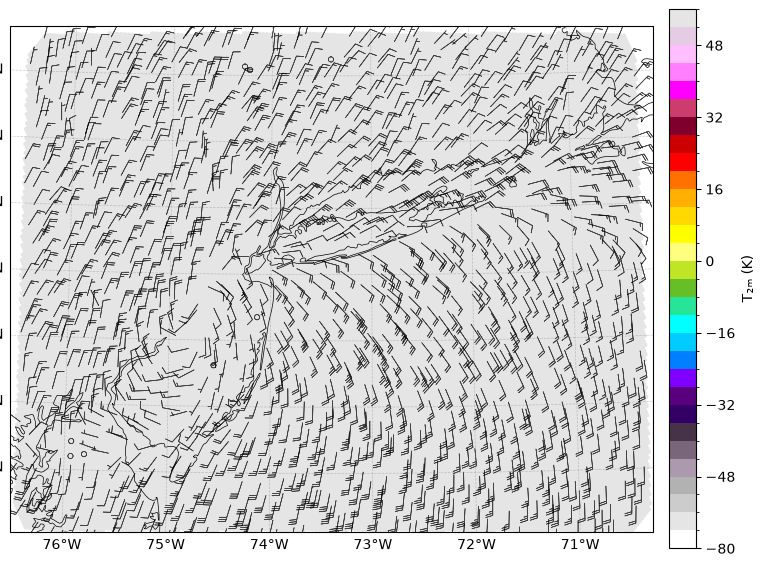

In [3]:
time_idx = 12  # During storm passage

# Get the temperature PolyCollection
cmap_t, norm_t = escmap("temp_ecmwf")
coll = mpasd.collection(dta, var_name='t2m', time_index=time_idx, figsize=(10, 10), cmap=cmap_t, norm=norm_t)

# Cell center coordinates and wind components
lon_cells = dta['face_x'].values
lat_cells = dta['face_y'].values
u = dta['u10'].isel(time=time_idx).values.flatten()
v = dta['v10'].isel(time=time_idx).values.flatten()

# Subsample for readability
N = 20
idx = np.arange(0, len(lon_cells), N)

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': coll.crs})
ax.add_collection(coll)
ax.autoscale_view()
ax.coastlines(linewidth=0.5)
ax.set_extent(coll.limits, crs=ccrs.PlateCarree())

# Wind barbs (convert m/s to knots: ×1.944)
ax.barbs(lon_cells[idx], lat_cells[idx],
         u[idx] * 1.944, v[idx] * 1.944,
         transform=ccrs.PlateCarree(),
         length=5, linewidth=0.5, color='black', alpha=0.7)

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', alpha=0.4, linestyle='--')
gl.top_labels = False
gl.right_labels = False

time_str = str(dta['time'].isel(time=time_idx).values.astype('datetime64[m]'))
ax.set_title(f"2m Temperature with 10m Wind Barbs\n{time_str}")
fig.colorbar(coll, ax=ax, shrink=0.7, pad=0.02, label='T₂ₘ (K)')

# Patch GeoAxes for Jupyter inline backend
_orig = ax.get_tightbbox
def _patch(renderer=None, **kw):
    bbox = _orig(renderer=renderer, **kw)
    if bbox is None or not np.isfinite(bbox.bounds).all():
        return ax.get_window_extent(renderer)
    return bbox
ax.get_tightbbox = _patch

### Quiver Plot over Precipitation
Wind arrows colored by wind speed, overlaid on rain rate.

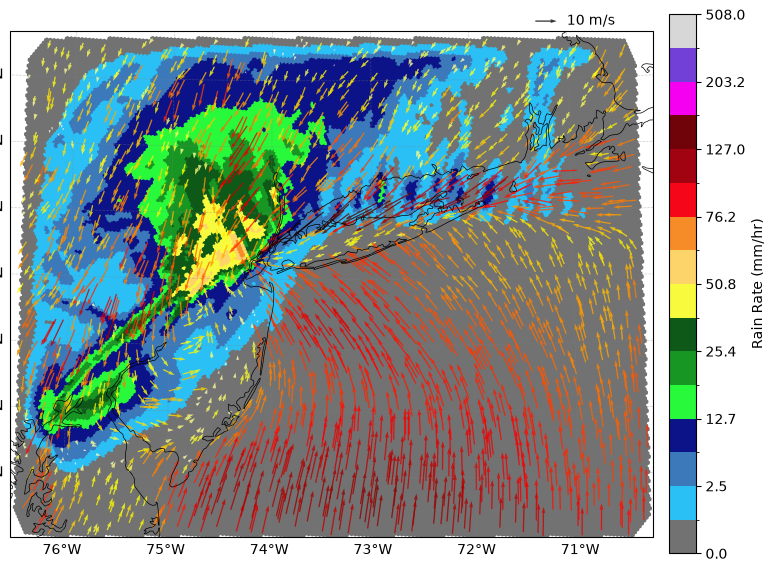

In [4]:
cmap_r, norm_r = escmap("nwps_qpe", units="mm")
coll = mpasd.collection(dta, var_name='rain_rate', time_index=time_idx, figsize=(10, 10), cmap=cmap_r, norm=norm_r)

wind_speed = np.sqrt(u**2 + v**2)

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': coll.crs})
ax.add_collection(coll)
ax.autoscale_view()
ax.coastlines(linewidth=0.5)
ax.set_extent(coll.limits, crs=ccrs.PlateCarree())

# Quiver with arrows colored by wind speed
N = 15
idx = np.arange(0, len(lon_cells), N)
q = ax.quiver(lon_cells[idx], lat_cells[idx],
              u[idx], v[idx],
              wind_speed[idx],
              transform=ccrs.PlateCarree(),
              cmap='hot_r', scale=300, width=0.002, alpha=0.8)

ax.quiverkey(q, 0.85, 1.02, 10, '10 m/s', labelpos='E')

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', alpha=0.4, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title(f"Rain Rate with Wind Vectors (colored by speed)\n{time_str}")
fig.colorbar(coll, ax=ax, shrink=0.7, pad=0.02, label='Rain Rate (mm/hr)')

_orig = ax.get_tightbbox
def _patch(renderer=None, **kw):
    bbox = _orig(renderer=renderer, **kw)
    if bbox is None or not np.isfinite(bbox.bounds).all():
        return ax.get_window_extent(renderer)
    return bbox
ax.get_tightbbox = _patch

### Streamlines
Smooth wind flow visualization. Requires interpolating from MPAS unstructured cells to a regular grid for `streamplot()`.

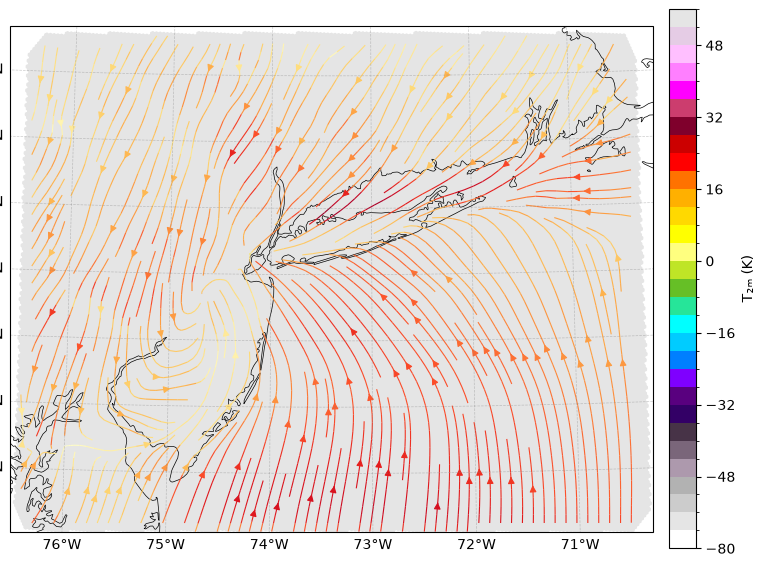

In [5]:
from scipy.interpolate import griddata

# Create regular grid for streamlines
lon_min, lon_max = float(dta['face_x'].min()), float(dta['face_x'].max())
lat_min, lat_max = float(dta['face_y'].min()), float(dta['face_y'].max())
grid_lon = np.linspace(lon_min, lon_max, 200)
grid_lat = np.linspace(lat_min, lat_max, 200)
grid_lon2d, grid_lat2d = np.meshgrid(grid_lon, grid_lat)

# Interpolate u, v to regular grid
points = np.column_stack([lon_cells, lat_cells])
u_grid = griddata(points, u, (grid_lon2d, grid_lat2d), method='linear')
v_grid = griddata(points, v, (grid_lon2d, grid_lat2d), method='linear')
speed_grid = np.sqrt(u_grid**2 + v_grid**2)

# Temperature background with streamlines
coll = mpasd.collection(dta, var_name='t2m', time_index=time_idx, figsize=(10, 10), cmap=cmap_t, norm=norm_t)

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': coll.crs})
ax.add_collection(coll)
ax.autoscale_view()
ax.coastlines(linewidth=0.5)
ax.set_extent(coll.limits, crs=ccrs.PlateCarree())

ax.streamplot(grid_lon, grid_lat, u_grid, v_grid,
              transform=ccrs.PlateCarree(),
              color=speed_grid, cmap='YlOrRd',
              density=2, linewidth=0.8, arrowsize=1)

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', alpha=0.4, linestyle='--')
gl.top_labels = False
gl.right_labels = False

ax.set_title(f"Temperature with Wind Streamlines\n{time_str}")
fig.colorbar(coll, ax=ax, shrink=0.7, pad=0.02, label='T₂ₘ (K)')

_orig = ax.get_tightbbox
def _patch(renderer=None, **kw):
    bbox = _orig(renderer=renderer, **kw)
    if bbox is None or not np.isfinite(bbox.bounds).all():
        return ax.get_window_extent(renderer)
    return bbox
ax.get_tightbbox = _patch